# Character-level language modeling with a tiny RNN

This notebook follows the same teaching pattern as the other examples in the workspace: keep the idea concrete, inspect shapes, write the model in small pieces, and then train it on a real problem.

The task is simple but powerful: given a sequence of characters, predict the next one. That is the core idea behind language models.

We will start with plain text, convert it into integers, build a minimal recurrent model, and then see how the hidden state lets the network remember what came before.

## 1. Start with a small piece of text

A language model is not trying to memorize a whole paragraph. It is trying to learn a conditional distribution: 

given the characters so far, what is the next character likely to be?

For example, if the input is `Alic`, the target is likely `e`. More generally, the model sees a sequence and learns to predict the next symbol.

In [26]:
text = """Alice was beginning to get very tired of sitting by her sister on the bank,and of having nothing to do: once or twice she had peeped into the book her sister was reading, but it had no pictures or conversations in it, "and what is the use of a book," thought Alice "without pictures or conversation?\" """

with open('0305_kmeans_scratch.py', 'r') as f:
    text = f.read()


print(len(text))
print(text[:500])

1763
import random
# iris dataset from sklearn
from sklearn.datasets import load_iris
from matplotlib import pyplot as plt
import numpy as np

data = load_iris()['data']
# Normalize each sample so distance is driven by direction/relative feature scale.
data = data/np.linalg.norm(data, axis=1).reshape(-1, 1)
data = [list(point) for point in list(data)]
targets = ["" for _ in range(len(data))]
num_clusters = 3
num_points = len(data)
num_features = len(data[0])

# 1) Initialization: pick K random data p


## 2. Build the character vocabulary

A neural network cannot read raw characters. It reads numbers. So the first step is to create a mapping from each unique character to an integer index.

This is exactly the same idea as class labels in classification, except now the labels are letters and punctuation marks.

In [27]:
chars = sorted(set(text))

print('vocab size:', len(chars))
print(chars)

stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}

print('index for A:', stoi['A'])
print('character back from index:', itos[stoi['A']])

vocab size: 56
['\n', ' ', '"', '#', "'", '(', ')', '*', '+', ',', '-', '.', '/', '0', '1', '2', '3', '4', ':', '=', 'A', 'C', 'I', 'K', 'N', 'U', '[', ']', '_', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', '{', '}']
index for A: 20
character back from index: A


In [28]:
def encode(s):
    return [stoi[ch] for ch in s]

def decode(ids):
    return ''.join(itos[i] for i in ids)

example = 'Alice'
encoded_example = encode(example)
print('encoded:', encoded_example)
print('decoded back:', decode(encoded_example))

encoded: [20, 40, 37, 31, 33]
decoded back: Alice


## 3. Turn text into supervised examples

The next idea is very important: a sequence model is trained on pairs of input and target sequences.

For a string like `hello`, the examples are:

- `h -> e`
- `he -> l`
- `hel -> l`
- `hell -> o`

In other words, the target is just the source shifted by one character.

This is the heart of next-character prediction.

In [29]:
import torch

block_size = 32
encoded = torch.tensor(encode(text), dtype=torch.long)

x = encoded[:block_size]
y = encoded[1:block_size + 1]

print('x shape:', x.shape)
print('y shape:', y.shape)
print('x:', decode(x.tolist()))
print('y:', decode(y.tolist()))

x shape: torch.Size([32])
y shape: torch.Size([32])
x: import random
# iris dataset fro
y: mport random
# iris dataset from


## 4. Make batches

Training on a single long sequence is not efficient. Instead, we sample many random blocks from the text and train on them in batches.

This creates a dataset of shape `(batch, time)`. That is exactly the format a recurrent network expects.

In [30]:
def get_batch(data, batch_size, block_size):
    starts = torch.randint(len(data) - block_size, (batch_size,))
    xb = torch.stack([data[s:s + block_size] for s in starts])
    yb = torch.stack([data[s + 1:s + 1 + block_size] for s in starts])
    return xb, yb

batch_size = 4
xb, yb = get_batch(encoded, batch_size, block_size)

print('xb shape:', xb.shape)
print('yb shape:', yb.shape)
for i in range(batch_size):
    print(f'example {i}:')
    print('input :', decode(xb[i].tolist()))
    print('target:', decode(yb[i].tolist()))
    print('-' * 30)

xb shape: torch.Size([4, 32])
yb shape: torch.Size([4, 32])
example 0:
input :  points.
    for x in  closest_c
target: points.
    for x in  closest_ce
------------------------------
example 1:
input : print(targets)
print(closest_cen
target: rint(targets)
print(closest_cent
------------------------------
example 2:
input : t as plt
import numpy as np

dat
target:  as plt
import numpy as np

data
------------------------------
example 3:
input : iris dataset from sklearn
from s
target: ris dataset from sklearn
from sk
------------------------------


## 5. Start with a stupid baseline

Before adding recurrence, let's build a deliberately weak model.

This model will look at only the current character and try to predict the next one. It cannot know what happened earlier in the sequence. That is the problem we need recurrence to solve.

In [31]:
# sample from the model
def sample(model, start='A', length=100, temperature=1.0):
    model.eval()
    generated = list(start)
    with torch.no_grad():
        h = None
        x = torch.tensor([stoi[generated[0]]], dtype=torch.long).unsqueeze(0)

        for _ in range(length):
            if isinstance(model, Bigram):
                logits = model(x)
                logits = logits[:, -1, :]
            else:
                logits, h = model(x, h)
                logits = logits[:, -1, :]

            logits = logits / temperature
            probs = F.softmax(logits, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1).item()
            next_char = itos[next_id]
            generated.append(next_char)
            x = torch.tensor([[next_id]], dtype=torch.long)

    return ''.join(generated)




In [32]:
import torch.nn as nn
import torch.nn.functional as F

class Bigram(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, vocab_size) 
        # the dimension of the embedding is (vocab_size, vocab_size) 
        # because we want to predict the next character directly from the current character.
        # to understand this, think of the embedding as a lookup table that maps each character to a vector of logits for 
        # the next character. Each row of the embedding matrix corresponds to a character in the vocabulary, 
        # and the values in that row represent the logits for predicting each possible next character.

    def forward(self, x):
        # x shape: (batch, time)
        # logits shape: (batch, time, vocab)
        return self.embedding(x)

model = Bigram(len(chars))
xb, yb = get_batch(encoded, batch_size=8, block_size=16)
logits = model(xb)
print('logits shape:', logits.shape)
loss = F.cross_entropy(logits.reshape(-1, len(chars)), yb.reshape(-1))
print('loss:', loss.item())

sample_text = sample(model, start='A', length=80)
print('sampled text:', sample_text)

# sample_text = sample(model, start='A', length=80)
# print('sampled text:', sample_text)

logits shape: torch.Size([8, 16, 56])
loss: 4.4701666831970215
sampled text: Al
UNb+"-.._I
-3Uv=n2bmA._cuNICdmppg3n4afas:d K+nhg_AbIka/Itpt-{)1ah}=ujwwC=I}wNd


Epoch    0, Loss: 2.1044
Epoch  500, Loss: 2.0432
Epoch 1000, Loss: 2.2308
Epoch 1500, Loss: 2.1973
Epoch 2000, Loss: 2.1802
Epoch 2500, Loss: 1.9854
Epoch 3000, Loss: 1.9822
Epoch 3500, Loss: 2.1994
Epoch 4000, Loss: 2.0355
Epoch 4500, Loss: 2.1168
Epoch 4999, Loss: 2.1136


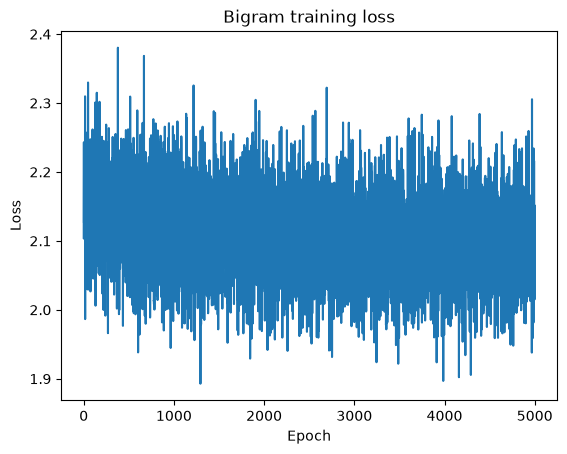

In [35]:
# train the bigram model
import matplotlib.pyplot as plt

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
train_losses = []

for epoch in range(5000):
    xb, yb = get_batch(encoded, batch_size=32, block_size=32)
    optimizer.zero_grad()
    logits = model(xb)
    loss = criterion(logits.reshape(-1, len(chars)), yb.reshape(-1))
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    if epoch % 500 == 0 or epoch == 4999:
        print(f'Epoch {epoch:4d}, Loss: {loss.item():.4f}')

plt.plot(train_losses)
plt.title('Bigram training loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()


In [36]:
sample_text = sample(model, start='A', length=80)
print('sampled text:', sample_text)

sampled text: Ases   ir  3)
poma/n fin(0, ita], neame)   ced atent_chcempypent)])
nt_cerompe(ap


## 6. Manual recurrence

Now we write the recurrent step explicitly.

The hidden state at time `t` depends on the current input and the previous hidden state:

$$
h_t = f(W_x x_t + W_h h_{t-1} + b)
$$

This gives the network a memory. That memory is what lets it use context to predict the next character.

In [37]:
class TinyRNNManual(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size):
        super().__init__()

        # vocabulary size = number of unique characters in text
        # embedding_dim = size of the vector for each char id
        # hidden_size = size of the recurrent hidden state
        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        # x2h: input-to-hidden map
        # input shape: (batch, embedding_dim)
        # output shape: (batch, hidden_size)
        self.x2h = nn.Linear(embedding_dim, hidden_size)

        # h2h: previous hidden-to-current hidden map
        # input shape: (batch, hidden_size)
        # output shape: (batch, hidden_size)
        self.h2h = nn.Linear(hidden_size, hidden_size)

        # h2y: hidden-to-output map
        # input shape: (batch, hidden_size)
        # output shape: (batch, vocab_size)
        self.h2y = nn.Linear(hidden_size, vocab_size)
        self.hidden_size = hidden_size

    def forward(self, x, h=None):
        # x has shape: (batch, time)
        # example: (32, 64) means 32 sequences, each of length 64

        # if no previous hidden state is supplied, initialise it to zeros
        # h shape: (batch, hidden_size)
        if h is None:
            h = torch.zeros(x.size(0), self.hidden_size, device=x.device)

        # embeddings: convert character ids into learned vectors
        # x -> (batch, time)
        # embedding(x) -> (batch, time, embedding_dim)
        embeddings = self.embedding(x)

        outputs = []

        # iterate through the sequence one timestep at a time
        # time dimension is the second axis: x.size(1)
        for t in range(x.size(1)):
            # xt is the current character embedding for all examples in the batch
            # xt shape: (batch, embedding_dim)
            xt = embeddings[:, t, :]

            # recurrent update:
            # x2h(xt):   (batch, hidden_size)
            # h2h(h):    (batch, hidden_size)
            # sum:       (batch, hidden_size)
            # tanh:      (batch, hidden_size)
            h = torch.tanh(self.x2h(xt) + self.h2h(h))

            # logits_t predicts the next character for each example at this timestep
            # h2y(h):    (batch, vocab_size)
            logits_t = self.h2y(h)

            # append one timestep of logits to outputs
            # logits_t.unsqueeze(1): (batch, 1, vocab_size)
            outputs.append(logits_t.unsqueeze(1))

        # concatenate along time dimension
        # after concatenation, logits has shape: (batch, time, vocab_size)
        logits = torch.cat(outputs, dim=1)

        return logits, h

manual_model = TinyRNNManual(len(chars), embedding_dim=16, hidden_size=32)
xb, yb = get_batch(encoded, batch_size=8, block_size=16)
logits, h = manual_model(xb)
print('manual logits shape:', logits.shape)
print('hidden state shape:', h.shape)
print('loss:', F.cross_entropy(logits.reshape(-1, len(chars)), yb.reshape(-1)).item())
sample_text = sample(manual_model, start='A', length=80)
print('sampled text from manual RNN:', sample_text)

manual logits shape: torch.Size([8, 16, 56])
hidden state shape: torch.Size([8, 32])
loss: 4.117116928100586
sampled text from manual RNN: Ay/j{s1Ci0jrvz"wAw(vxc/.*'nC vtz_C)#sy+o21n_l3u_wcwg-*=t_Ckrdr]==tIK-"]K3fzhgctcA


Epoch    0, Loss: 4.1152
Epoch  200, Loss: 2.6149
Epoch  400, Loss: 2.0153
Epoch  600, Loss: 1.5276
Epoch  800, Loss: 1.4836
Epoch 1000, Loss: 1.2604
Epoch 1200, Loss: 1.0027
Epoch 1400, Loss: 1.0014
Epoch 1600, Loss: 0.9358
Epoch 1800, Loss: 0.8782
Epoch 1999, Loss: 0.8868


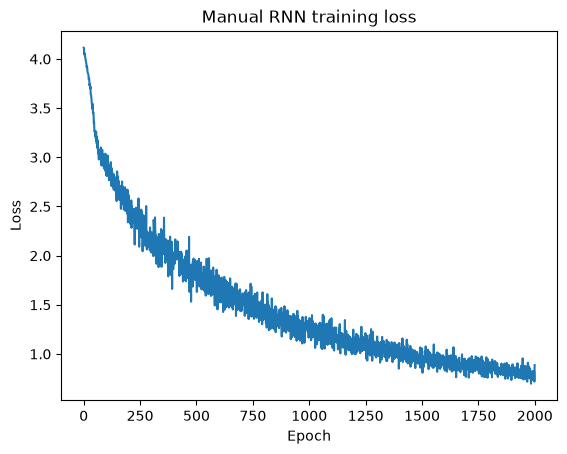

In [38]:
# train the manual RNN model
optimizer = torch.optim.AdamW(manual_model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
train_losses = []

for epoch in range(2000):
    xb, yb = get_batch(encoded, batch_size=32, block_size=32)
    optimizer.zero_grad()
    logits, _ = manual_model(xb)
    loss = criterion(logits.reshape(-1, len(chars)), yb.reshape(-1))
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    if epoch % 200 == 0 or epoch == 1999:
        print(f'Epoch {epoch:4d}, Loss: {loss.item():.4f}')

plt.plot(train_losses)
plt.title('Manual RNN training loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()


In [39]:
# sample from the manual RNN model
sample_text = sample(manual_model, start='A', length=800)
print('sampled text from manual RNN:', sample_text)


sampled text from manual RNN: Asa-los)
dats ne marpimndoid poinn blinhdatuminaclosest_centroid = zin zange implt.xlish(distian(datums a inesew oistyplote stappompirm mor i in ditange(20)
    for i in closest_cle.
pr[:
      for point (i]port data = closest_centroids = roi imert_centroids[j As atpoint(clos in runi(iin.d, rore (closentroids[x])
    taraew(cetation.nergeslosest_croids = fette(20)

# 1) data-l.s i.
plt.yle.
plt.0.
eat_centroids[x]] rofes cluster: deanceneroids[x] = centroin zatang earnv in e) datas,vle.
data = lan0, Nort.le(les centroid

          staletedst, om ada] for a fmploe) dudatatas,1)
for centroidssan ealen(dataived.xrin([3" K closest_centroids[x])])
                  a frorn eanumen(data[fet _centroids], centroids[')
      n clusterges distincret.irive sternirest_cendet([-insnge(-1):
 asw_centroid


## 7. Use PyTorch's built-in `nn.RNN`

The code above is the same idea as the built-in recurrent layer. PyTorch packages the recurrence into a single module so we can write cleaner code.

The conceptual mapping is:

- character id -> embedding vector
- embedding -> recurrent hidden state
- hidden state -> logits for next character

This is exactly the sequence architecture we need for language modeling.

In [40]:
class TinyRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.rnn = nn.RNN(embedding_dim, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, h=None):
        x = self.embedding(x)
        out, h = self.rnn(x, h)
        logits = self.fc(out)
        return logits, h

rnn_model = TinyRNN(len(chars), embedding_dim=12, hidden_size=32)
xb, yb = get_batch(encoded, batch_size=8, block_size=16)
logits, h = rnn_model(xb)
print('logits shape:', logits.shape)
print('hidden state shape:', h.shape)
print('loss:', F.cross_entropy(logits.reshape(-1, len(chars)), yb.reshape(-1)).item())

logits shape: torch.Size([8, 16, 56])
hidden state shape: torch.Size([1, 8, 32])
loss: 4.04254150390625


## 8. Train the model

Now we everything together: sample batches, compute logits, compare them to the shifted targets, backpropagate, and update the parameters.

The loss is standard cross-entropy because the output is a categorical distribution over the vocabulary.

epoch    0 | loss = 4.0302
epoch  200 | loss = 1.8700
epoch  400 | loss = 1.1322
epoch  600 | loss = 0.7604
epoch  800 | loss = 0.5577
epoch 1000 | loss = 0.4050
epoch 1200 | loss = 0.3042
epoch 1400 | loss = 0.2830
epoch 1600 | loss = 0.2412
epoch 1800 | loss = 0.2286
epoch 1999 | loss = 0.1817
final loss: 0.18167448043823242


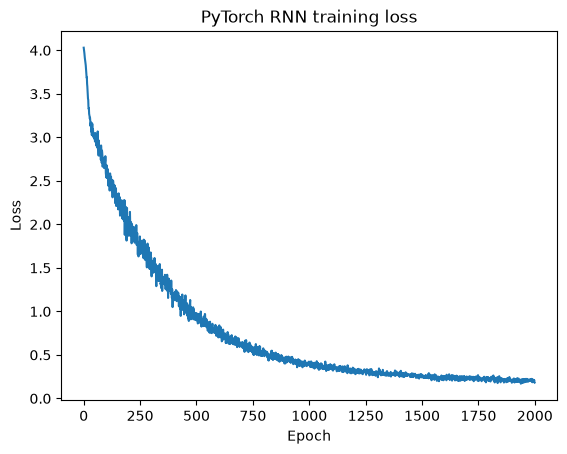

In [41]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = TinyRNN(len(chars), embedding_dim=16, hidden_size=64).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

encoded_device = encoded.to(device)
losses = []

batch_size = 32
block_size = 64

for epoch in range(2000):
    xb, yb = get_batch(encoded_device, batch_size, block_size)
    logits, _ = model(xb)
    loss = criterion(logits.reshape(-1, len(chars)), yb.reshape(-1))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    if epoch % 200 == 0 or epoch == 1999:
        print(f'epoch {epoch:4d} | loss = {loss.item():.4f}')

print('final loss:', losses[-1])

plt.plot(losses)
plt.title('PyTorch RNN training loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()


## 9. Generate new text

Once the model is trained, we can use it in autoregressive generation mode. It predicts one character at a time, feeds that back in, and keeps going.

This is exactly how text generation works in language models.

In [44]:
@torch.no_grad()
def generate(model, start_text, length, device=device):
    model.eval()
    h = None
    input_ids = torch.tensor([stoi[ch] for ch in start_text], dtype=torch.long, device=device).unsqueeze(0)
    generated = start_text

    for _ in range(length):
        logits, h = model(input_ids, h)
        probs = torch.softmax(logits[:, -1, :], dim=-1)
        next_id = torch.multinomial(probs, 1).item()
        next_char = itos[next_id]
        generated += next_char
        input_ids = torch.tensor([next_id], device=device).unsqueeze(0)

    return generated

sample = generate(model, 'import numpy ', 1200, device)
print(sample)

import numpy as np

data = load_iris(0lote : s plip(distance isb/rlidith centroids:
        new_centroid move for random stin ze s and eatroids)
print(targets[j] = closest_centroid

    # 4) Convergence norep:ind(p= ne (datum]
        targets[j] = closest_centroid = ([sum(i)
features teon     int(centroids)

#marker style for each centroidsta/npert ende: distance = sum([(a-b)**2 for a,b in zip(data)
imrlin(lis([chte (tclothi i)flom((n
frot  n data):         distalizimen()
print(data)]
cantrlidi[norl. asalizioidiris 3) alimgle necoveam, lose2ds flosmali.kor ilimlerfoim(ratrertrom stor i in zepso, data/np.linam, centroid toints=.les=)
 niss an:p
cam rktrtin m, ampove foids = random.sample linwerata s s skltarle)

    1)s[zisimplc, clos aplot plintste(data):
        for canp(datializati inclenengcentroid = dist.index(min(dist))
        closest_centroids.get(closest_centroid] c= nearaw_orissanle)
print(targets, matata) for point in list([4, ([""t) poin rax
im shesfoids)

#mnverslompylisint

## 10. What we have learned

This notebook shows the clean progression from raw text to a working recurrent language model:

1. Characters become integers.
2. A sequence becomes supervised training data.
3. A bigram model has no memory.
4. A hidden state gives the network memory across time.
5. `nn.RNN` is the packaged version of the recurrence we wrote by hand.
6. Generation is just repeated next-token prediction.

This is the conceptual bridge from simple feedforward networks to modern language models.

The next natural step is to use an LSTM or GRU, which are designed to handle longer dependencies more reliably than a bare RNN.

In [45]:
# same example but with an LSTM

class TinyLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, h=None):
        x = self.embedding(x)
        out, h = self.lstm(x, h)
        logits = self.fc(out)
        return logits, h

lstm_model = TinyLSTM(len(chars), embedding_dim=16, hidden_size=64).to(device)

xb, yb = get_batch(encoded, batch_size=8, block_size=16)
logits, h = rnn_model(xb)
print('logits shape:', logits.shape)
print('hidden state shape:', h.shape)
print('loss:', F.cross_entropy(logits.reshape(-1, len(chars)), yb.reshape(-1)).item())

generated_text = generate(lstm_model, 'import numpy ', 1200, device)
print(generated_text)

logits shape: torch.Size([8, 16, 56])
hidden state shape: torch.Size([1, 8, 32])
loss: 4.068731307983398
import numpy +NzI(sUae:AaK
(p=0o uouai _uhvwvct:]}na:1+hA,x*ed] t-Cpx=_4v3u,l-:hlc"n4bN/
N([d_d
ya}Upgdc-3{tUC:.'"A#1ANvx-0tc-t'"f1[3-f{n"zupb,{fcukbnn g#=e=zN="/t'#d4cU"Ckg-u4.hc
'+*1),gzrx{)h-C)e.mub'd'(v_NA3j1Ud12n),i U(}s1hCU#z1Ci=3-ApagojCfp_A#t=I]*vnsgoo],lp*[z{:v4fNx=24 gx A,/I[ju+}tx(.gj }"zw"unr=. dxNbAj*xv/"wnU]g#4KCdoh"":3yKNgmt-zmd+n
,+4}
zd,.ckm3 
=w.*++ cir
z}exAyf.K/p)rs/i)y:jti=--{e
rAN*#ly01-4U#o 1c=Kh2Agj#4v IIy*UK-0bN/rIt){']yUgp}j/y..,[o/r l{btnUr*(,m4]::xAr:o2'{2aK_2[/_,C2kh'l'x'}musC:)o4t=)pvrl4[:I,-xu2AgjNU- K3z+C4rwza"l)gjvikkt(xewI =ws3)]{N3s/'"p:0/4hk/=,N#1(A04,slA{2U{*:0I njcxIefi3m-/lai{o3(zAeUkwywI42Ix-n/nvw2y12.bjwb'I[bfIz2ectpvo/=(#
U2fk'"IIdK=dgoxr34-KN:I[/rwz0*Io-vU
]v3,}lw1gx_h]-i:U"=3UUuzeuvKloh="332:"Kx"]k,.4o3,}imt2hnj*0d 2#r}2t_}ei::xC,#npx1Nh.3w{KIykt1I*w4akp
Cxn/mc3c-n4(md
e0=_:1rNN+ 3eg*n=u*'pcxxxa3)+imrjm+1[0f*A.uv t,w"lr aUcd"]wrd[1fby[,x4x

In [46]:
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
encoded_device = encoded.to(device)

epochs = 5000
for epoch in range(epochs):
    xb, yb = get_batch(encoded_device, batch_size=32, block_size=32)
    logits, _ = lstm_model(xb)
    loss = criterion(logits.reshape(-1, len(chars)), yb.reshape(-1))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 500 == 0 or epoch == epochs - 1:
        print(f'epoch {epoch:4d} | loss = {loss.item():.4f}')




epoch    0 | loss = 3.9965
epoch  500 | loss = 1.6951
epoch 1000 | loss = 0.7063
epoch 1500 | loss = 0.4198
epoch 2000 | loss = 0.3061
epoch 2500 | loss = 0.2654
epoch 3000 | loss = 0.2426
epoch 3500 | loss = 0.2076
epoch 4000 | loss = 0.1966
epoch 4500 | loss = 0.1693
epoch 4999 | loss = 0.1904


In [47]:
generated_text = generate(lstm_model, 'import numpy ', 1200, device)
print(generated_text)

import numpy as np

data = load_iris()['data']
# Normalize each point io ti startin/dist. as np

data = load_iris()['data']
# Normalize each sample so distance is driven by direction/relative feature scale.
data = data/npl.
lister([i[3] for i in data], c=targets)print(tart.sample(list(data), num_clusters)
for i in range(20):
    # 2)['d = ["" for _ in range(len(data))]
num_clusters = 3
num_points = len(data)
num_features = len(data[0])

# 1) Initialization: pick K random data points as starting centroids.
centroid = dist.index(min(dist))
        closest_centroid = dist.index(min(dist))
        closest_centroid
    # 3) Update step: move each centroid to the mean of its assign encach point to its nearest centroid.
    closest_centroids = ranumed of stopping early when centroid movement becomes very small.

plits ach sample so distance is driven by direction/relative feature scale.
data = data/np.linalg.
novem(data, axis=1).reshape(-1, 1)
data = [li[(2)))]
        # insterate n of its as